In [1]:
# Cell 1 — install required libraries
import subprocess
subprocess.run(["pip", "install", "sentence-transformers", "umap-learn"])
print("Done!")

Done!


In [2]:
import subprocess
subprocess.run(["pip", "install", "plotly umap-learn sentence-transformers"])
print("Done!")

Done!


In [4]:
import subprocess

libraries = [
    "nltk",
    "pandas",
    "numpy",
    "matplotlib",
    "plotly",
    "sentence-transformers",
    "umap-learn",
    "bertopic",
    "wordcloud",
    "streamlit",
    "scikit-learn",
    "seaborn",
    "tqdm"
]

for lib in libraries:
    print("Installing", lib, "...")
    subprocess.run(["pip", "install", lib])

print("\nAll libraries installed!")

Installing nltk ...
Installing pandas ...
Installing numpy ...
Installing matplotlib ...
Installing plotly ...
Installing sentence-transformers ...
Installing umap-learn ...
Installing bertopic ...
Installing wordcloud ...
Installing streamlit ...
Installing scikit-learn ...
Installing seaborn ...
Installing tqdm ...

All libraries installed!


In [5]:
# Cell 2 — imports
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import plotly.express as px

print("Imports done!")

Imports done!


In [6]:
# Cell 3 — load processed data
df = pd.read_csv("E:/Research Paper topic/data/processed_papers.csv")
texts = df['clean_text'].tolist()
print("Loaded", len(texts), "papers")
print("Sample text:", texts[0][:150])

Loaded 300 papers
Sample text: bora bridging offline reinforcement learning online residual adaptation realworld dexterous vla model visionlanguageaction vla model emerged promising


In [7]:
# Cell 4 — load model and generate embeddings (takes 3-5 minutes)
print("Loading SBERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded! Now generating embeddings...")

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    batch_size=64
)

np.save("E:/Research Paper topic/data/embeddings.npy", embeddings)
print("Embeddings shape:", embeddings.shape)
print("Saved embeddings!")

Loading SBERT model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2860.31it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded! Now generating embeddings...


Batches: 100%|██████████| 5/5 [00:09<00:00,  1.80s/it]

Embeddings shape: (300, 384)
Saved embeddings!


In [8]:
# Cell 5 — reduce to 2D with UMAP (takes 1-2 minutes)
print("Running UMAP dimensionality reduction...")

reducer = umap.UMAP(
    n_components=2,
    random_state=42,
    n_neighbors=15,
    min_dist=0.1
)
embeddings_2d = reducer.fit_transform(embeddings)

df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

df.to_csv("E:/Research Paper topic/data/processed_papers.csv", index=False)
print("UMAP done! Coordinates saved to CSV.")

Running UMAP dimensionality reduction...


c:\Users\ramki\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done! Coordinates saved to CSV.


In [9]:
# Cell 6 — visualize 2D scatter plot
fig = px.scatter(
    df,
    x='umap_x',
    y='umap_y',
    hover_data=['title', 'year'],
    title="Research papers in 2D embedding space (before clustering)",
    opacity=0.6,
    width=900,
    height=600
)
fig.show()

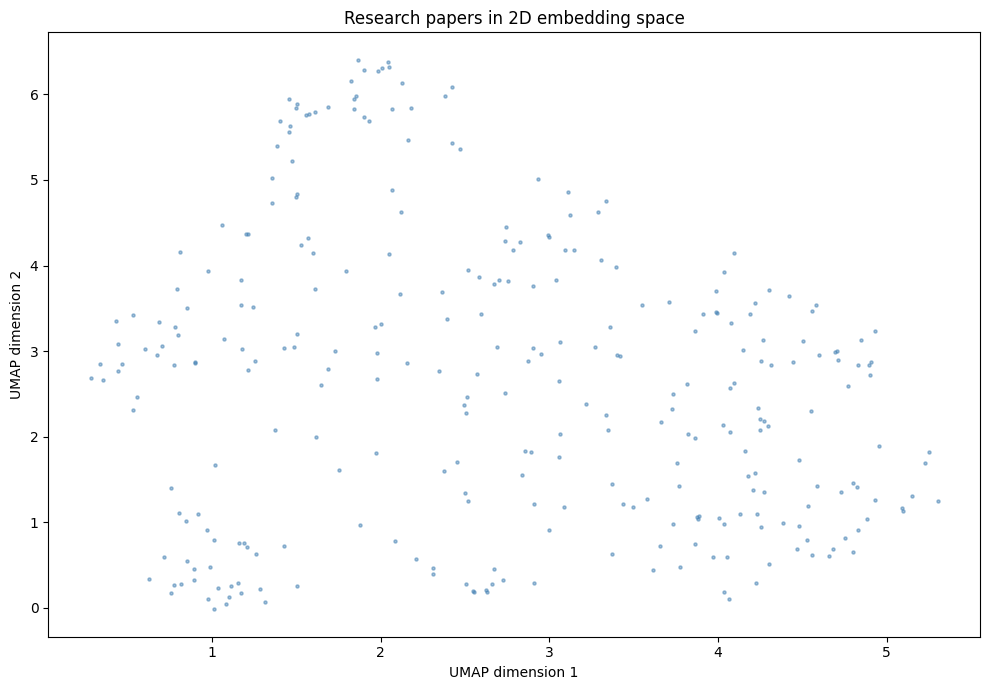

In [10]:
# Cell 7 — simple matplotlib version (backup if plotly doesn't show)
plt.figure(figsize=(10, 7))
plt.scatter(df['umap_x'], df['umap_y'], s=5, alpha=0.5, color='steelblue')
plt.title("Research papers in 2D embedding space")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.tight_layout()
plt.show()